## Tips

- **Start simple** — a single GRU with 64 units is a good first attempt.
  Only add complexity (stacking, dropout, bidirectional) if the simple model
  is clearly underfitting or overfitting.

- **Use many epochs** — RNNs on time series converge slowly. 10 or 20 epochs
  is almost never enough. Use **at least 100 epochs** and let early stopping
  decide when to stop. The best checkpoint is saved automatically by
  `ModelCheckpoint` — you will not miss the optimal point even if you
  train for too long.

- **Watch the train/val gap** — if train MAE is much lower than val MAE
  you are overfitting. Add dropout, reduce `hidden_size`, or increase
  early stopping patience to give regularization more time to work.

- **Use TensorBoard** — run `tensorboard --logdir runs` in your terminal
  to monitor train and val curves in real time. A healthy training curve
  shows both losses decreasing together. A diverging val curve means overfitting.

- **Learning rate matters** — if the loss is not decreasing after the first
  few epochs, try a lower learning rate (`1e-4` instead of `1e-3`).
  Use `ReduceLROnPlateau` to automatically decay the learning rate when
  val MAE stops improving.

- **The sklearn baseline is hard to beat** — `HistGradientBoosting` with
  explicit lag features is a very strong baseline for tabular time series.
  This is not a failure of the RNN — it reflects a fundamental difference
  between the two approaches: tree models get temporal information from
  hand-crafted features, while RNNs must learn it from raw sequences.
  Getting within 10 bikes/hour of the sklearn baseline (< 44 bikes/hour)
  is an excellent result.

In [1]:
!pip install tensorboard -q

In [2]:
import os
import numpy as np
import joblib

from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn

from torch.utils.tensorboard import SummaryWriter

In [3]:
save_dir = "data/bike_processed"

# --- Load arrays ---
raw_data     = np.load(os.path.join(save_dir, "raw_data.npy"))
counts       = np.load(os.path.join(save_dir, "counts.npy"))
train_idx    = np.load(os.path.join(save_dir, "train_idx.npy"))
val_idx      = np.load(os.path.join(save_dir, "val_idx.npy"))
test_idx     = np.load(os.path.join(save_dir, "test_idx.npy"))
naive_mae    = np.load(os.path.join(save_dir, "naive_mae.npy"))
preprocessor = joblib.load(os.path.join(save_dir, "preprocessor_rnn.pkl"))

# --- Split sizes ---
num_train = len(train_idx)
num_val   = len(val_idx)
num_test  = len(test_idx)

# --- Count stats: mean y std del training set (sin leakage) ---
# Si Part 1 no guardo count_stats.npy, se computa aqui
stats_path = os.path.join(save_dir, "count_stats.npy")
if os.path.exists(stats_path):
    count_stats = np.load(stats_path)
else:
    count_stats = np.array([counts[:num_train].mean(), counts[:num_train].std()])
    np.save(stats_path, count_stats)

count_mean = count_stats[0]
count_std  = count_stats[1]

print(f"raw_data shape:    {raw_data.shape}")
print(f"counts shape:      {counts.shape}")
print(f"train/val/test:    {num_train} / {num_val} / {num_test}")
print(f"counts range:      {counts.min():.0f} to {counts.max():.0f} bikes/hour")
print(f"count mean/std:    {count_mean:.2f} / {count_std:.2f}")
print(f"\nNaive baseline — Val MAE: {naive_mae[0]:.2f} | Test MAE: {naive_mae[1]:.2f} bikes/hour")

raw_data shape:    (17210, 28)
counts shape:      (17210,)
train/val/test:    12047 / 2581 / 2582
counts range:      1 to 977 bikes/hour
count mean/std:    161.75 / 153.40

Naive baseline — Val MAE: 93.26 | Test MAE: 80.78 bikes/hour


In [4]:
count_norm = (counts - count_mean) / count_std

In [5]:
class TimeseriesDataset(Dataset):
    def __init__(self, data, targets, sequence_length, sampling_rate, 
                 start_index, end_index, shuffle=False):
        self.data            = data
        self.targets         = targets
        self.sequence_length = sequence_length
        self.sampling_rate   = sampling_rate

        # Valid starting indices: each sequence of length sequence_length
        # sampled every sampling_rate steps needs:
        # (sequence_length - 1) * sampling_rate + 1 rows ahead
        self.indices = np.arange(start_index, end_index)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        start = self.indices[idx]
        # Sample every `sampling_rate` steps for `sequence_length` steps
        steps = np.arange(start, start + self.sequence_length * self.sampling_rate, 
                          self.sampling_rate)
        x = self.data[steps]
        # Target is `delay` steps ahead of the sequence start
        y = self.targets[start + delay]
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

In [6]:
sampling_rate   = 1    # already hourly
sequence_length = 24   # look back 24 hours
delay           = 1    # predict 1 hour ahead
batch_size      = 256

train_dataset = TimeseriesDataset(
    data=raw_data, targets=count_norm,
    sequence_length=sequence_length, sampling_rate=sampling_rate,
    start_index=0, end_index=num_train,
)
val_dataset = TimeseriesDataset(
    data=raw_data, targets=count_norm,
    sequence_length=sequence_length, sampling_rate=sampling_rate,
    start_index=num_train, end_index=num_train + num_val,
)
#test_dataset = TimeseriesDataset(
#    data=raw_data, targets=count_norm,
#    sequence_length=sequence_length, sampling_rate=sampling_rate,
#    start_index=num_train + num_val, end_index=len(raw_data) - delay,
#)
test_dataset = TimeseriesDataset(
    data=raw_data, targets=count_norm,
    sequence_length=sequence_length, sampling_rate=sampling_rate,
    start_index=num_train + num_val,
    end_index=len(raw_data) - sequence_length * sampling_rate,  # fix
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

# --- Sanity check ---
inputs, targets = next(iter(train_loader))
print(f"Input shape:  {inputs.shape}")   # (256, 24, num_features)
print(f"Target shape: {targets.shape}")  # (256,)
print(f"Target range: {targets.min():.0f} to {targets.max():.0f}")

Input shape:  torch.Size([256, 24, 28])
Target shape: torch.Size([256])
Target range: -1 to 4


## Definicion del modelo — GRU

Se implementa una red neuronal recurrente basada en **GRU** (Gated Recurrent Unit).
El GRU es preferido sobre el LSTM en este contexto porque:

- Tiene menos parametros (2 gates vs 3), lo que reduce el riesgo de overfitting
  en datasets de tamano mediano como este (~12k ejemplos de entrenamiento).
- Suele converger mas rapido con resultados equivalentes o mejores en series de tiempo
  de horizonte corto (24h).

### Arquitectura

```
Input  (batch, 24, 28)
  |
GRU    hidden_size=64, num_layers=1
  |    -> toma el ultimo timestep: (batch, 64)
Dropout(0.2)
  |
Linear (64 -> 1)
  |
Output (batch,)  <- prediccion normalizada
```

La salida es un escalar normalizado; se desnormaliza al evaluar el MAE en bikes/hour.

In [7]:
class BikeGRU(nn.Module):
    """GRU para forecasting univariado de demanda de bicicletas."""
    def __init__(self, input_size, hidden_size=64, num_layers=1, dropout=0.2):
        super().__init__()
        self.gru = nn.GRU(
            input_size, hidden_size,
            num_layers=num_layers,
            batch_first=True,
            # dropout entre capas solo si hay mas de 1 capa
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_size, 1)
        )

    def forward(self, x):
        # x: (batch, seq_len, input_size)
        out, _ = self.gru(x)          # (batch, seq_len, hidden_size)
        out    = out[:, -1, :]        # ultimo timestep: (batch, hidden_size)
        return self.head(out).squeeze(-1)  # (batch,)


class EarlyStopping:
    """Detiene el entrenamiento si val MAE no mejora y guarda el mejor modelo."""
    def __init__(self, patience=20, min_delta=0.3, path='best_gru.pt'):
        self.patience  = patience
        self.min_delta = min_delta
        self.path      = path
        self.best      = np.inf
        self.counter   = 0

    def step(self, val_mae, model):
        if val_mae < self.best - self.min_delta:
            self.best = val_mae
            torch.save(model.state_dict(), self.path)
            self.counter = 0
            return False   # continuar
        self.counter += 1
        return self.counter >= self.patience   # True = detener


# Verificar que el modelo produce la forma correcta
device     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
INPUT_SIZE = raw_data.shape[1]   # 28 features
_dummy     = BikeGRU(INPUT_SIZE).to(device)
with torch.no_grad():
    _x = torch.randn(4, 24, INPUT_SIZE).to(device)
    print(f'Output shape: {_dummy(_x).shape}')   # (4,)
    print(f'Params: {sum(p.numel() for p in _dummy.parameters()):,}')
del _dummy

Output shape: torch.Size([4])
Params: 18,113


## Configuracion del entrenamiento

| Hiperparametro | Valor | Razon |
|---|---|---|
| `hidden_size` | 64 | Punto de partida recomendado; escalar si underfits |
| `dropout` | 0.2 | Regularizacion ligera |
| `lr` | 1e-3 | Valor tipico para Adam en RNNs |
| `batch_size` | 256 | Ya definido en la celda de DataLoaders |
| `N_EPOCHS` | 150 | Early stopping decide el punto optimo |
| `patience` | 20 | Epocas sin mejora antes de detener |

**Loss:** MSE sobre targets normalizados (gradientes mas estables).
**Metrica:** MAE en bikes/hour (desnormalizado — interpretable).
**Scheduler:** `ReduceLROnPlateau` — divide lr x2 si val MAE no mejora en 8 epocas.

In [8]:
HIDDEN_SIZE = 64
NUM_LAYERS  = 1
DROPOUT     = 0.2
LR          = 1e-3
N_EPOCHS    = 150

model     = BikeGRU(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS, DROPOUT).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=8, factor=0.5
)
early_stopping = EarlyStopping(patience=20, min_delta=0.3, path='best_gru.pt')

print(f'Device:      {device}')
print(f'Model params: {sum(p.numel() for p in model.parameters()):,}')

Device:      cpu
Model params: 18,113


## Loop de entrenamiento

Cada epoca:
1. **train_epoch** — forward + backward + clip gradients (max_norm=1.0) + Adam step
2. **evaluate_mae** — inferencia sin gradientes, desnormaliza y computa MAE en bikes/hour
3. **ReduceLROnPlateau** — ajusta lr si val MAE no mejora
4. **EarlyStopping** — guarda checkpoint si hay mejora; para si no hay mejora en 20 epocas

In [9]:
import matplotlib.pyplot as plt


def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(X), y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        running_loss += loss.item() * len(y)
    return running_loss / len(loader.dataset)


@torch.no_grad()
def evaluate_mae(model, loader, device, mean, std):
    """MAE en bikes/hour (escala original)."""
    model.eval()
    preds, trues = [], []
    for X, y in loader:
        preds.append(model(X.to(device)).cpu().numpy())
        trues.append(y.numpy())
    preds = np.concatenate(preds) * std + mean
    trues = np.concatenate(trues) * std + mean
    return float(np.mean(np.abs(preds - trues)))


# ── Training loop ────────────────────────────────────────────────────────
history = {'train_loss': [], 'val_mae': []}

for epoch in range(1, N_EPOCHS + 1):
    train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
    val_mae    = evaluate_mae(model, val_loader, device, count_mean, count_std)

    scheduler.step(val_mae)
    history['train_loss'].append(train_loss)
    history['val_mae'].append(val_mae)

    if epoch % 10 == 0 or epoch == 1:
        lr = optimizer.param_groups[0]['lr']
        print(f'Epoch {epoch:3d} | train MSE: {train_loss:.4f} | val MAE: {val_mae:.2f} bikes/h | lr: {lr:.1e}')

    if early_stopping.step(val_mae, model):
        print(f'\nEarly stopping en epoca {epoch}')
        break

print(f'\nMejor val MAE: {early_stopping.best:.2f} bikes/hour')

Epoch   1 | train MSE: 0.7034 | val MAE: 134.58 bikes/h | lr: 1.0e-03
Epoch  10 | train MSE: 0.1151 | val MAE: 54.69 bikes/h | lr: 1.0e-03
Epoch  20 | train MSE: 0.0704 | val MAE: 45.45 bikes/h | lr: 1.0e-03
Epoch  30 | train MSE: 0.0552 | val MAE: 46.71 bikes/h | lr: 1.0e-03
Epoch  40 | train MSE: 0.0461 | val MAE: 38.71 bikes/h | lr: 5.0e-04
Epoch  50 | train MSE: 0.0443 | val MAE: 38.78 bikes/h | lr: 2.5e-04
Epoch  60 | train MSE: 0.0418 | val MAE: 38.48 bikes/h | lr: 2.5e-04
Epoch  70 | train MSE: 0.0395 | val MAE: 39.09 bikes/h | lr: 1.3e-04

Early stopping en epoca 75

Mejor val MAE: 37.92 bikes/hour


## Evaluacion del desempeno

Se carga el mejor checkpoint guardado por EarlyStopping y se evalua sobre
val y test. Los resultados se comparan contra los dos baselines de la Parte 1.

| Modelo | Val MAE | Test MAE |
|---|---|---|
| Naive baseline | 93.26 | 80.78 |
| HistGradientBoosting | 35.02 | 33.94 |
| **GRU (ours)** | ? | ? |

In [10]:
# Cargar el mejor checkpoint
model.load_state_dict(torch.load('best_gru.pt', map_location=device))

final_val_mae  = evaluate_mae(model, val_loader,  device, count_mean, count_std)
final_test_mae = evaluate_mae(model, test_loader, device, count_mean, count_std)

NAIVE_VAL, NAIVE_TEST = naive_mae[0], naive_mae[1]
GBRT_VAL,  GBRT_TEST  = 35.02, 33.94

print('=' * 52)
print(f'{"Modelo":<22} {"Val MAE":>12} {"Test MAE":>12}')
print('-' * 52)
print(f'{"Naive baseline":<22} {NAIVE_VAL:>12.2f} {NAIVE_TEST:>12.2f}')
print(f'{"HistGradientBoosting":<22} {GBRT_VAL:>12.2f} {GBRT_TEST:>12.2f}')
print(f'{"GRU (ours)":<22} {final_val_mae:>12.2f} {final_test_mae:>12.2f}')
print('=' * 52)

mejora_naive = (NAIVE_TEST - final_test_mae) / NAIVE_TEST * 100
print(f'\nMejora sobre naive:  {mejora_naive:.1f}%')
gap_gbrt = final_test_mae - GBRT_TEST
print(f'Gap vs HistGB:       {gap_gbrt:+.2f} bikes/hour')

Modelo                      Val MAE     Test MAE
----------------------------------------------------
Naive baseline                93.26        80.78
HistGradientBoosting          35.02        33.94
GRU (ours)                    37.92        37.26

Mejora sobre naive:  53.9%
Gap vs HistGB:       +3.32 bikes/hour


## Analisis de resultados

### Curvas de entrenamiento
Muestran si el modelo convergio correctamente y si hay overfitting.
Un entrenamiento saludable muestra train loss y val MAE descendiendo juntos.

### Predicciones vs real
Visualiza las primeras 2 semanas del test set para evaluar cualitativamente
si el modelo captura los patrones diarios y semanales de la demanda.

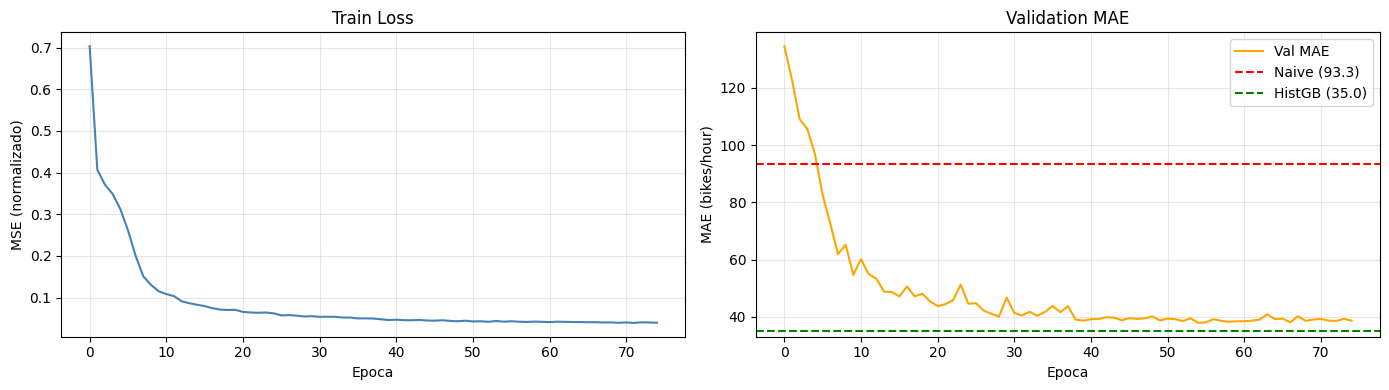

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Train loss
axes[0].plot(history['train_loss'], color='steelblue')
axes[0].set_xlabel('Epoca')
axes[0].set_ylabel('MSE (normalizado)')
axes[0].set_title('Train Loss')
axes[0].grid(alpha=0.3)

# Val MAE con referencias
axes[1].plot(history['val_mae'], color='orange', label='Val MAE')
axes[1].axhline(NAIVE_VAL,  color='red',   linestyle='--', label=f'Naive ({NAIVE_VAL:.1f})')
axes[1].axhline(GBRT_VAL,   color='green', linestyle='--', label=f'HistGB ({GBRT_VAL:.1f})')
axes[1].set_xlabel('Epoca')
axes[1].set_ylabel('MAE (bikes/hour)')
axes[1].set_title('Validation MAE')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

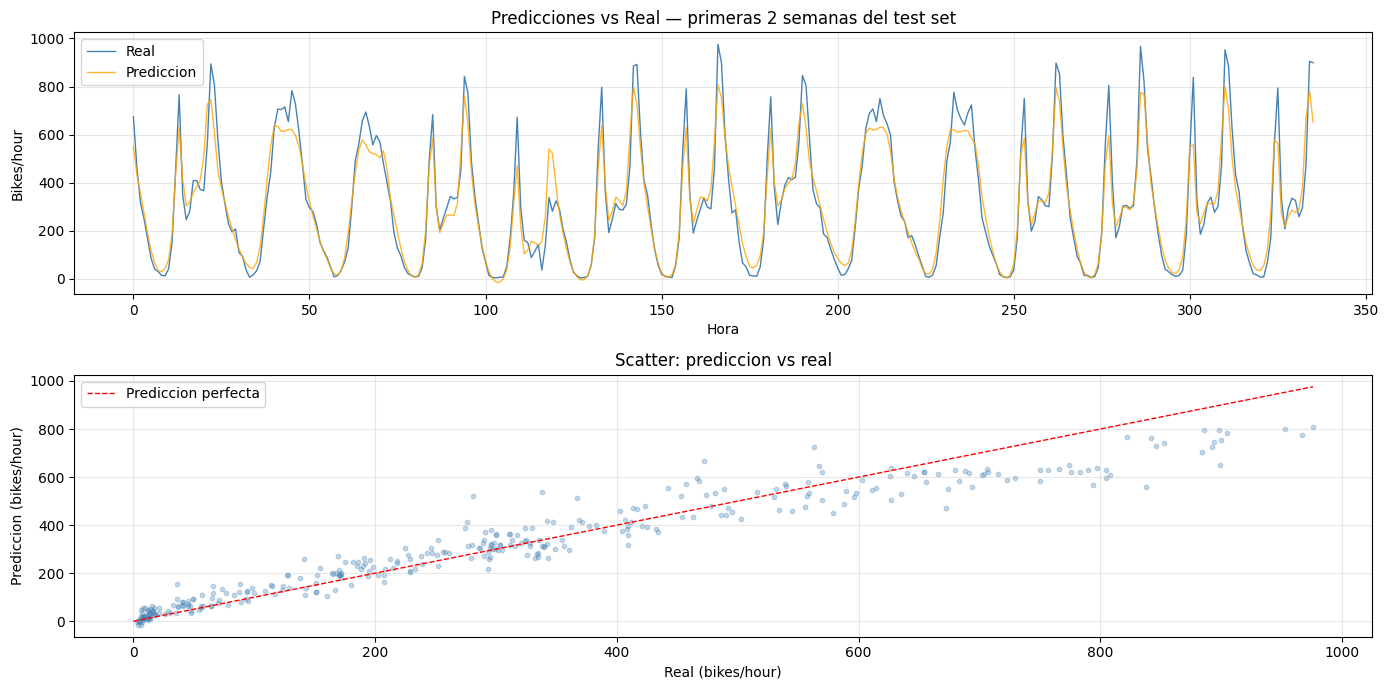

In [12]:
# Recolectar predicciones del test set
model.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for X, y in test_loader:
        all_preds.append(model(X.to(device)).cpu().numpy())
        all_true.append(y.numpy())

preds_raw = np.concatenate(all_preds) * count_std + count_mean
trues_raw = np.concatenate(all_true)  * count_std + count_mean

# Primeras 2 semanas del test
n_show = 24 * 14
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

axes[0].plot(trues_raw[:n_show], label='Real',      linewidth=1.0, color='steelblue')
axes[0].plot(preds_raw[:n_show], label='Prediccion', linewidth=1.0, color='orange', alpha=0.8)
axes[0].set_xlabel('Hora')
axes[0].set_ylabel('Bikes/hour')
axes[0].set_title('Predicciones vs Real — primeras 2 semanas del test set')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Scatter: prediccion vs real
axes[1].scatter(trues_raw[:n_show], preds_raw[:n_show], alpha=0.3, s=10, color='steelblue')
lim = max(trues_raw[:n_show].max(), preds_raw[:n_show].max())
axes[1].plot([0, lim], [0, lim], 'r--', linewidth=1.0, label='Prediccion perfecta')
axes[1].set_xlabel('Real (bikes/hour)')
axes[1].set_ylabel('Prediccion (bikes/hour)')
axes[1].set_title('Scatter: prediccion vs real')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()